Запустите, пожалуйста, раздел "Подготовка" и приступайте к выполнению заданий.

## Подготовка

### Импорт библиотек

In [ ]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

### Загрузка датасета и подготовка данных

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=False)

# Загрузка подготовленных данных
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/audio_data_mean.pickle', None, quiet=True)

Downloading...
From: https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip
To: /content/genres.zip
100%|██████████| 1.23G/1.23G [00:58<00:00, 20.9MB/s]


'audio_data_mean.pickle'

In [ ]:
# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
!ls genres

# Проверка содержимого одной папки


blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock


In [ ]:
# Установка констант

FILE_DIR = './genres'                     # Папка с файлами датасета
CLASS_LIST = os.listdir(FILE_DIR)         # Список классов, порядок меток не определен!
CLASS_LIST.sort()                         # Сортировка списка классов для фиксации порядка меток
CLASS_COUNT = len(CLASS_LIST)             # Количество классов
CLASS_FILES = 100                         # Общее количество файлов в каждом классе
FILE_INDEX_TRAIN_SPLIT = 90               # Количество файлов каждого класса на основной набор
VALIDATION_SPLIT = 0.1                    # Доля проверочной выборки в основном наборе
DURATION_SEC = 30                         # Анализируемая длительность аудиосигнала
N_FFT = 8192                              # Размер окна преобразования Фурье для расчета спектра
HOP_LENGTH = 512                          # Объем данных для расчета одного набора признаков

In [ ]:
# Проверка списка классов
print(CLASS_LIST)

['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [ ]:
# Функция параметризации аудио

def get_features(y,                     # волновое представление сигнала
                 sr,                    # частота дискретизации сигнала y
                 n_fft=N_FFT,           # размер скользящего окна БПФ
                 hop_length=HOP_LENGTH  # шаг скользящего окна БПФ
                 ):
    # Вычисление различных параметров (признаков) аудио

    # Хромаграмма
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Мел-кепстральные коэффициенты
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Среднеквадратическая амплитуда
    rmse = librosa.feature.rms(y=y, hop_length=hop_length)
    # Спектральный центроид
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Ширина полосы частот
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Спектральный спад частоты
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length)
    # Пересечения нуля
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=hop_length)

    # Сборка параметров в общий список:
    # На один файл один усредненный вектор признаков
    features = {'rmse': rmse.mean(axis=1, keepdims=True),
                'spct': spec_cent.mean(axis=1, keepdims=True),
                'spbw': spec_bw.mean(axis=1, keepdims=True),
                'roff': rolloff.mean(axis=1, keepdims=True),
                'zcr' : zcr.mean(axis=1, keepdims=True),
                'mfcc': mfcc.mean(axis=1, keepdims=True),
                'stft': chroma_stft.mean(axis=1, keepdims=True)}

    return features

In [ ]:
# Функция объединения признаков в набор векторов

def stack_features(feat  # словарь признаков, отдельные векторы по ключу каждого признака
                   ):
    features = None
    for v in feat.values():
        features = np.vstack((features, v)) if features is not None else v

    return features.T

In [ ]:
# Функция формирования набора признаков и метки класса для аудиофайла

def get_feature_list_from_file(class_index,  # индекс класса файла song_name
                               song_name,    # имя аудиофайла
                               duration_sec  # длительность аудио в секундах
                               ):
    # Загрузка в y первых duration_sec секунд аудиосигнала
    y, sr = librosa.load(song_name, mono=True, duration=duration_sec)

    # Извлечение параметров из аудиосигнала
    features = get_features(y, sr)
    feature_set = stack_features(features)

    # Перевод номера класса в one hot encoding
    y_label = to_categorical(class_index, CLASS_COUNT)

    return feature_set, y_label

In [ ]:
# Функция формирования подвыборки признаков и меток класса для одного файла

def process_file(class_index,  # индекс класса аудиофайла
                 file_index,   # индекс (порядковый номер) аудиофайла в папке класса
                 duration_sec  # длительность аудио в секундах
                 ):
    x_list = []
    y_list = []
    class_name = CLASS_LIST[class_index]

    # Извлечение имени произведения
    song_name = f'{FILE_DIR}/{class_name}/{class_name}.{str(file_index).zfill(5)}.au'

    # Выборка признаков и метки класса для произведения
    feature_set, y_label = get_feature_list_from_file(class_index,
                                                        song_name,
                                                        duration_sec)

    # Добавление данных в наборы
    for j in range(feature_set.shape[0]):
        x_list.append(feature_set[j])
        y_list.append(y_label)

    # Возврат имени файла и numpy-массивов призанков и меток класса
    return song_name, \
           np.array(x_list).astype('float32'), \
           np.array(y_list).astype('float32')

In [ ]:
# Функция формирования набора данных из файлов всех классов по диапазону номеров файлов

def extract_data(file_index_start,          # начальный индекс аудиофайла
                 file_index_end,            # конечный индекс аудиофайла (не достигая)
                 duration_sec=DURATION_SEC  # длительность аудио в секундах
                 ):

    # Списки для последовательностей входных данных и меток класса
    x_data = None
    y_data = None

    # Фиксация времени старта формирования выборки
    curr_time = time.time()

    # Для всех классов:
    for class_index in range(len(CLASS_LIST)):
        # Для всех файлов текущего класса из заданного диапазона номеров:
        for file_index in range(file_index_start, file_index_end):
            # Обработка одного файла и добавление данных к общим массивам
            _, file_x_data, file_y_data = process_file(class_index, file_index, duration_sec)
            x_data = file_x_data if x_data is None else np.vstack([x_data, file_x_data])
            y_data = file_y_data if y_data is None else np.vstack([y_data, file_y_data])

        # Вывод информации о готовности обработки датасета
        print(f'Жанр {CLASS_LIST[class_index]} готов -> {round(time.time() - curr_time)} c')
        curr_time = time.time()

    # Возврат массивов набора данных
    return x_data, y_data

In [ ]:
# Восстановление датасета аудио
# Данные привязаны к порядку следования меток классов!
# Порядок классов фиксирован сортировкой списка меток классов

with open('/content/audio_data_mean.pickle', 'rb') as f:
    x_train_data, y_train_data = pickle.load(f)

In [ ]:
# Нормирование признаков в соответствии со стандартным нормальным распределением

x_scaler = StandardScaler()
x_train_data_scaled = x_scaler.fit_transform(x_train_data)

In [ ]:
# Разделение набора данных на обучающую и проверочную выборки
# Параметр stratify указывает метки классов, по которым происходит балансировка разделения

x_train, x_val, y_train, y_val = train_test_split(x_train_data_scaled,
                                                  y_train_data,
                                                  stratify=y_train_data,
                                                  test_size=VALIDATION_SPLIT)

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
# Преобразование обучающих данных в тензоры PyTorch
x_train_t = torch.tensor(x_train, dtype=torch.float32)
# Преобразуем one-hot метки в индексы классов
y_train_t = torch.argmax(torch.tensor(y_train, dtype=torch.float32), dim=1)

x_val_t = torch.tensor(x_val, dtype=torch.float32)
y_val_t = torch.argmax(torch.tensor(y_val, dtype=torch.float32), dim=1)
# Создаем датасет
train_dataset = TensorDataset(x_train_t, y_train_t)
val_dataset = TensorDataset(x_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

### Функция вывода графиков точности и ошибки по эпохам обучения

In [ ]:
# Вывод графиков точности и ошибки распознавания на обучающей и проверочной выборках

def show_history(history  # объект-результат метода обучения .fit()
                 ):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'],
               label='Доля верных ответов на обучающем наборе')
    ax1.plot(history.history['val_accuracy'],
               label='Доля верных ответов на проверочном наборе')
    ax1.xaxis.get_major_locator().set_params(integer=True)
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающем наборе')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочном наборе')
    ax2.xaxis.get_major_locator().set_params(integer=True)
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

### Функции визуализации распознавания отдельных звуковых файлов

In [ ]:
def classify_file_torch(model,        # обученная модель классификатора (PyTorch)
                        x_scaler,     # настроенный нормировщик входных данных
                        class_index,  # верный индекс класса аудиофайла
                        file_index    # индекс (порядковый номер) аудиофайла в папке
                        ):
    # Подготовка выборки данных файла произведения
    song_name, file_x_data, file_y_data = process_file(class_index, file_index, DURATION_SEC)

    # Нормирование признаков уже настроенным нормировщиком
    file_x_data = x_scaler.transform(file_x_data)

    print('Файл:', song_name)
    print('Векторы для предсказания:', file_x_data.shape)

    # Преобразование данных в тензор PyTorch
    x_tensor = torch.tensor(file_x_data, dtype=torch.float32)

    # Вычисление предсказания по выборке
    model.eval()
    with torch.no_grad():
        outputs = model(x_tensor)
        predict = torch.softmax(outputs, dim=1).numpy()

    # Определение среднего предсказания (голосование)
    predict_mean = predict.mean(axis=0)
    # Определение индекса класса по результату голосования
    predict_class_index = np.argmax(predict_mean)
    # Вычисление признака правильного предсказания
    predict_good = predict_class_index == class_index

    # Визуализация предсказания сети для файла
    plt.figure(figsize=(10, 3))
    print('Классификация сети:', CLASS_LIST[predict_class_index], '-', 'ВЕРНО :-)' if predict_good else 'НЕВЕРНО.')
    plt.title('Среднее распределение векторов предсказаний')
    plt.bar(CLASS_LIST, predict_mean, color='g' if predict_good else 'r')
    plt.show()
    print('---------------------------------------------------------------')

    # Возврат результата предсказания
    return predict_class_index

In [ ]:
def classify_test_files_torch(model,       # обученная модель классификатора (PyTorch)
                              x_scaler,    # настроенный нормировщик входных данных
                              from_index,  # индекс аудиофайла, с которого начинать визуализацию
                              n_files      # количество файлов для визуализации
                              ):
    predict_all = 0
    predict_good = 0
    y_true = []
    y_pred = []

    # Классификация каждого файла и аккумуляция результатов классификации
    for class_index in range(CLASS_COUNT):
        for file_index in range(from_index, from_index + n_files):
            predict_class_index = classify_file_torch(model, x_scaler, class_index, file_index)
            y_true.append(class_index)
            y_pred.append(predict_class_index)
            predict_all += 1
            predict_good += (predict_class_index == class_index)

    # Расчет и вывод итогов классификации
    good_ratio = round(predict_good / predict_all * 100., 2)
    print(f'=== Обработано образцов: {predict_all}, из них распознано верно: {predict_good}, доля верных: {good_ratio}% ===')

    # Построение матрицы ошибок без нормализации, покажет попадания в штуках
    cm = confusion_matrix(y_true, y_pred)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title('Матрица ошибок по файлам аудио (не нормализованная)')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_LIST)
    disp.plot(ax=ax)
    plt.show()

##Заданиe

В предыдущих ячейках были подготовлены все данные для обучения модели нейронной сети.
1. Проверьте форму данных обучающей и проверочной выборок (выведите на экран).

In [ ]:
# Ваше решение
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

print("x_val shape:", x_val.shape)
print("y_val shape:", y_val.shape)

x_train shape: (810, 37)
y_train shape: (810, 10)
x_val shape: (90, 37)
y_val shape: (90, 10)


2. Составьте модель классификатора на полносвязных слоях и сохраните ее в переменной **model**. Для этого:
 - Используйте заготовку для последовательной модели **Sequential**;
 - Добавьте полносвязный слой на **64** нейрона с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **30%**;
 - Добавьте следующий полносвязный слой на **32** нейрона с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **30%**;
 - Добавьте следующий полносвязный слой на **16** нейронов с активационной функцией **'relu'**, после него добавьте слой **Dropout** с долей отключаемых нейронов **20%**;
 - Добавьте слой пакетной нормализации;
 - Добавьте финальный полносвязный слой классификатора на число нейронов по числу классов (**CLASS_COUNT**) с активационной функцией **'softmax'** .

In [ ]:
class AudioClassifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(AudioClassifier, self).__init__()

        self.net = nn.Sequential(
            #расширяем представление признаков до 64 нейронов
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Второй слой: сжатие до 32 признаков
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.BatchNorm1d(16),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
input_dim = x_train.shape[1]
model = AudioClassifier(input_dim, CLASS_COUNT)

3. Откомпилируйте созданную модель методом `.compile()` с указанием оптимизатора **Adam** и начальным шагом обучения **0.0001**, функцией ошибки **'categorical_crossentropy'** и метрикой **'accuracy'**;
Выведите на экран сводку архитектуры полученной модели методом `.summary()` .

In [ ]:
# Ваше решение
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
print(model)

AudioClassifier(
  (net): Sequential(
    (0): Linear(in_features=37, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): Linear(in_features=16, out_features=10, bias=True)
  )
)


4. Обучите модель и выведите графики обучения:
 - Обучите созданную и откомпилированную модель классификатора на данных обучающей выборки **x_train, y_train**, используя проверочные данные **x_val, y_val**, размер батча **32** и количество эпох **1000**. Результаты обучения сохраните в переменной **history** .
 - В разделе **"Функция вывода графиков точности и ошибки по эпохам обучения"** найдите определение функции `show_history()`, изучите требуемые параметры для нее и используйте для построения графиков точности и ошибки на протяжении эпох обучения.

In [ ]:
# Ваше решение
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

epochs = 1000

for epoch in range(epochs):
    model.train()

    train_loss = 0
    correct = 0
    total = 0
    # Итерация по батчам обучающей выборки
    for xb, yb in train_loader:
        optimizer.zero_grad()

        outputs = model(xb)
        # Вычисление ошибки
        loss = criterion(outputs, yb)

        loss.backward()
         # Обновление весов модели
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        true = yb

        correct += (preds == true).sum().item()
        total += yb.size(0)

    train_acc = correct / total
    train_loss = train_loss / len(train_loader)

    # РЕЖИМ ВАЛИДАЦИИ
    model.eval() # отключаем dropout и batchnorm обучение
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for xb, yb in val_loader:
          # Прямой проход: получаем логиты
            outputs = model(xb)
            # Вычисляем функцию потерь между предсказанием и истинными метками
            loss = criterion(outputs, yb)
            # Суммируем loss по всем батчам
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            true = yb

            correct += (preds == true).sum().item()
            # Считаем общее количество примеров
            total += yb.size(0)

    val_acc = correct / total
    val_loss = val_loss / len(val_loader)

    # log
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

In [ ]:
class HistoryAdapter:
    def __init__(self, history):
        self.history = {
            "accuracy": history["train_acc"],
            "val_accuracy": history["val_acc"],
            "loss": history["train_loss"],
            "val_loss": history["val_loss"]
        }

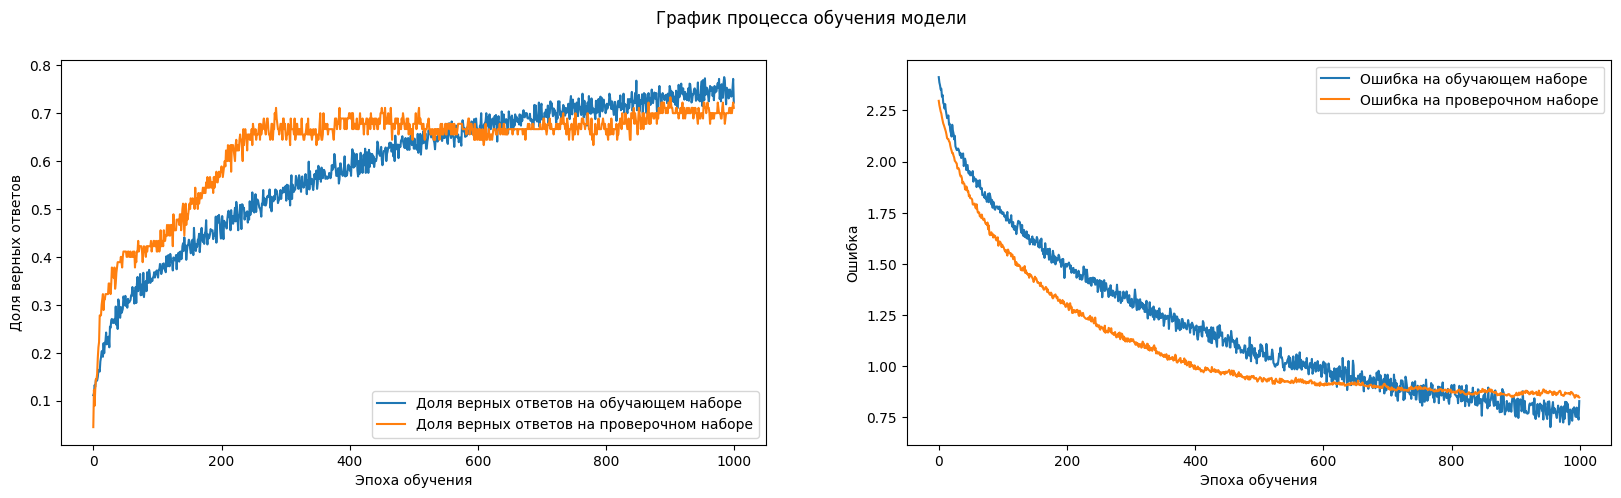

In [ ]:
show_history(HistoryAdapter(history))

5. Проверьте работу модели:
 - В разделе **Функции визуализации распознавания отдельных звуковых файлов** найдите определение функции `classify_test_files()` и изучите ее параметры. Используйте функцию для визуализации работы классификатора на произвольном количестве тестовых звуковых файлов, полагая, что:
 - вы используете обученная в задании 4 модель классификатора аудио;
 - нормализатор **x_scaler** уже настроен ранее в ноутбуке, и его нужно передать в функцию `classify_test_files()` вместо параметра **x_scaler**;
 - тестовые звуковые файлы начинаются с индекса **90** и всего их ровно **10** для каждого класса.

Файл: ./genres/blues/blues.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


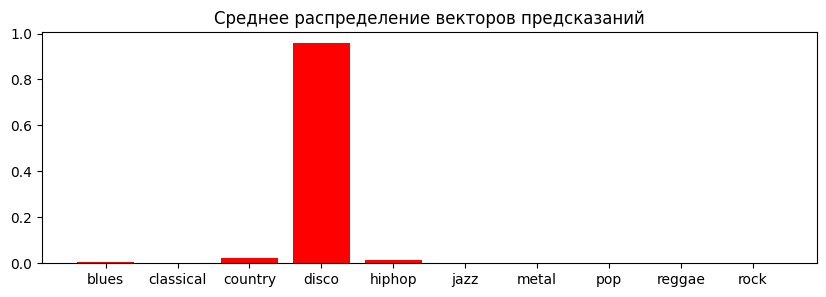

---------------------------------------------------------------
Файл: ./genres/blues/blues.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


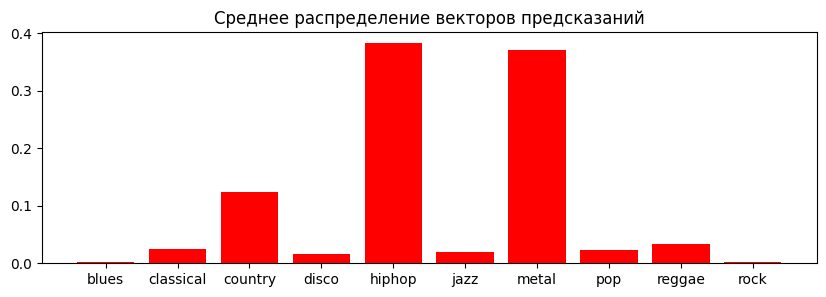

---------------------------------------------------------------
Файл: ./genres/blues/blues.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


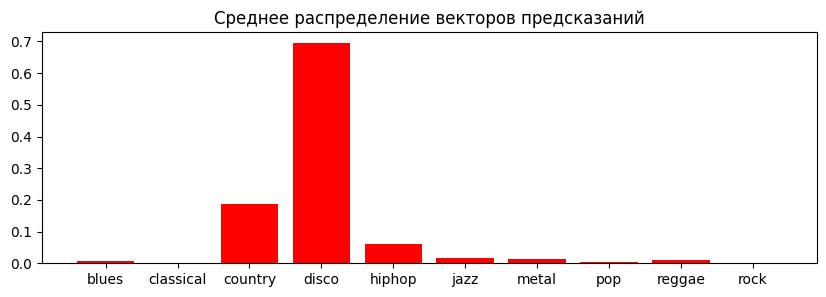

---------------------------------------------------------------
Файл: ./genres/blues/blues.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


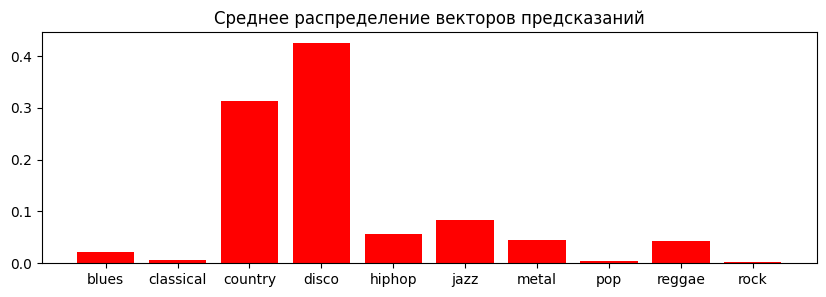

---------------------------------------------------------------
Файл: ./genres/blues/blues.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


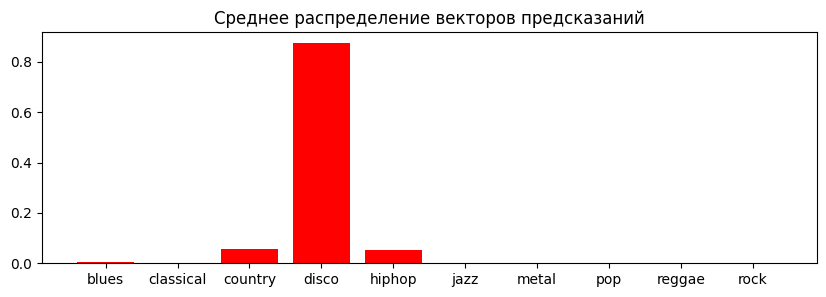

---------------------------------------------------------------
Файл: ./genres/blues/blues.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


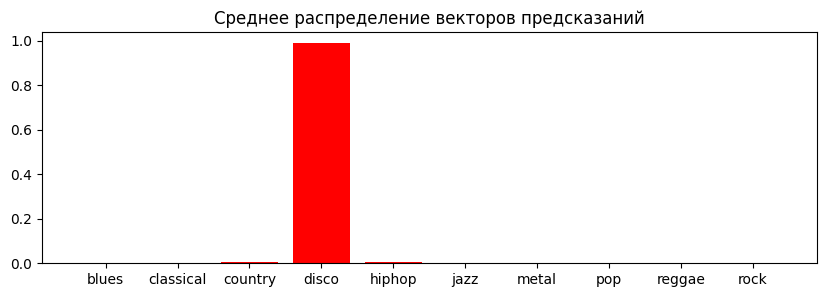

---------------------------------------------------------------
Файл: ./genres/blues/blues.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


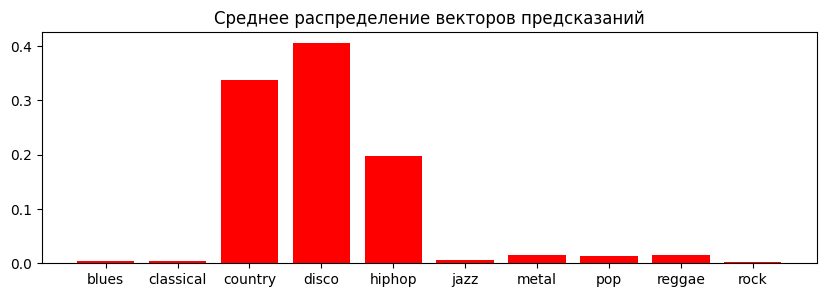

---------------------------------------------------------------
Файл: ./genres/blues/blues.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


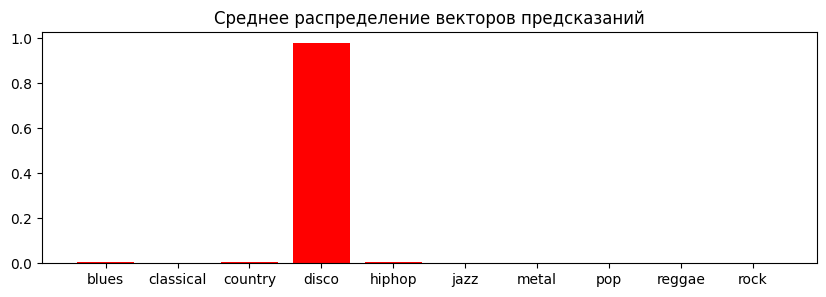

---------------------------------------------------------------
Файл: ./genres/blues/blues.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - ВЕРНО :-)


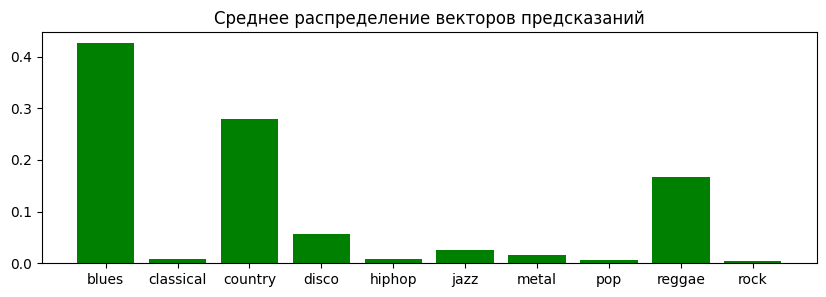

---------------------------------------------------------------
Файл: ./genres/blues/blues.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


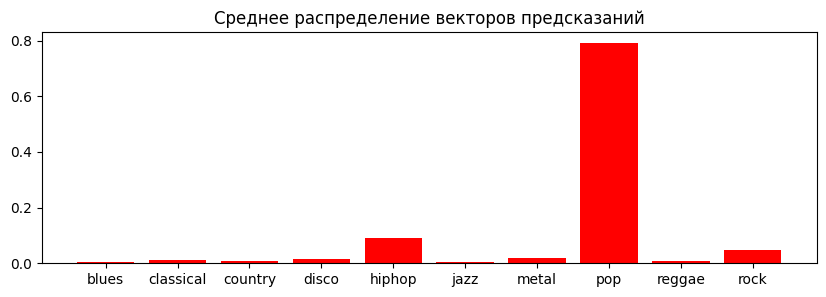

---------------------------------------------------------------
Файл: ./genres/classical/classical.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


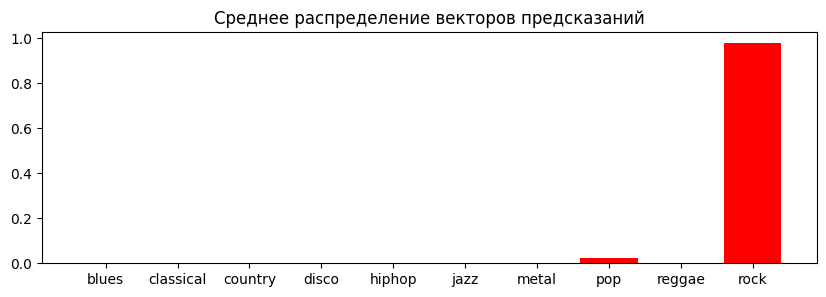

---------------------------------------------------------------
Файл: ./genres/classical/classical.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


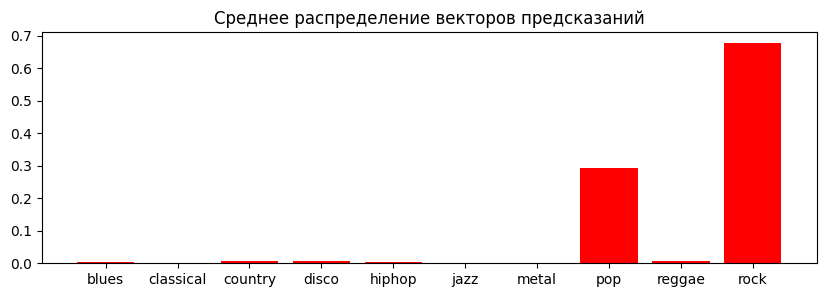

---------------------------------------------------------------
Файл: ./genres/classical/classical.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


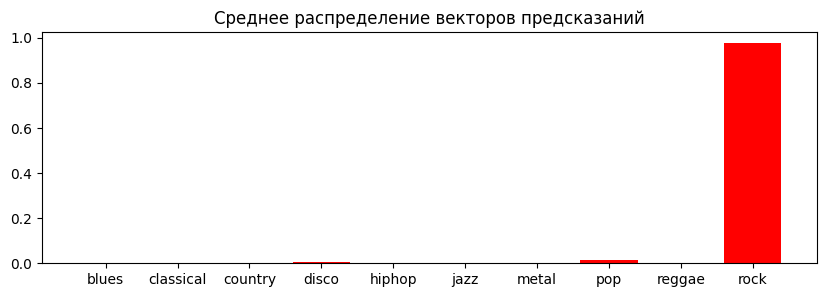

---------------------------------------------------------------
Файл: ./genres/classical/classical.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


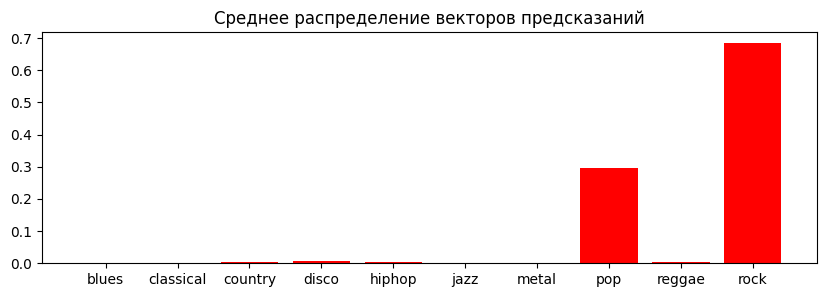

---------------------------------------------------------------
Файл: ./genres/classical/classical.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


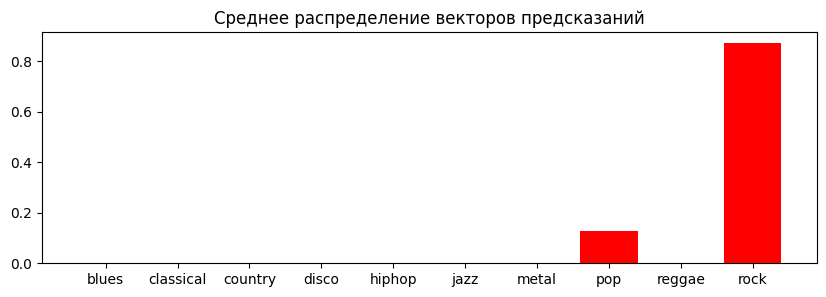

---------------------------------------------------------------
Файл: ./genres/classical/classical.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


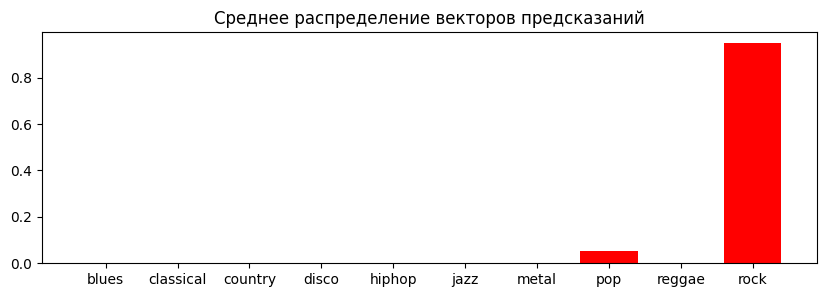

---------------------------------------------------------------
Файл: ./genres/classical/classical.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


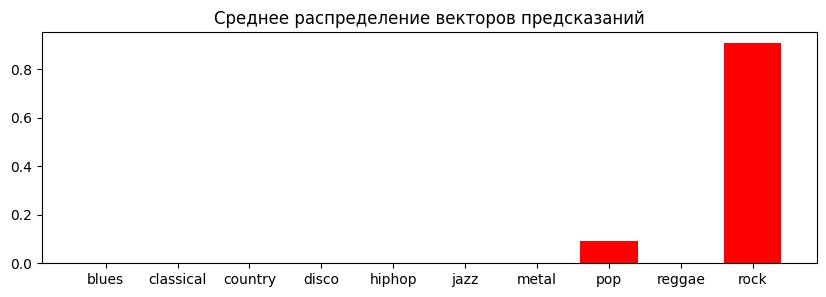

---------------------------------------------------------------
Файл: ./genres/classical/classical.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


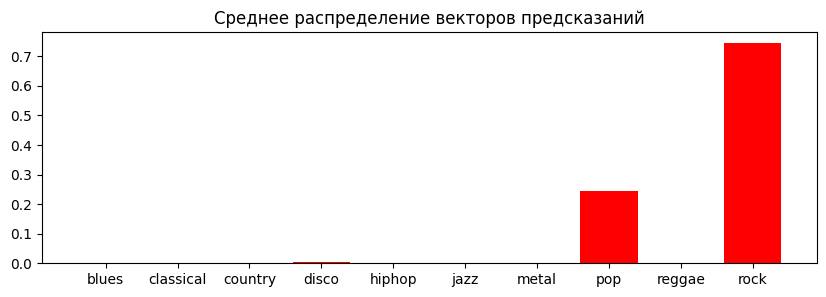

---------------------------------------------------------------
Файл: ./genres/classical/classical.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


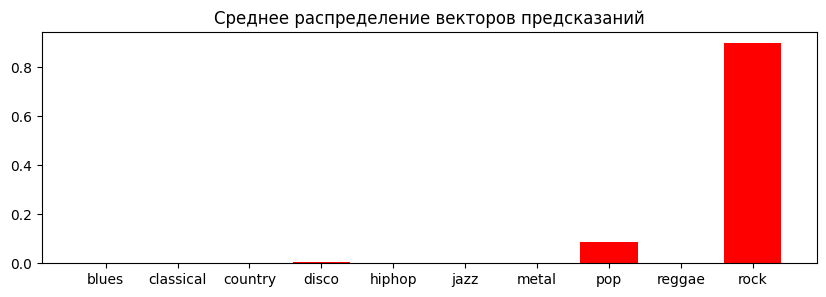

---------------------------------------------------------------
Файл: ./genres/classical/classical.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: rock - НЕВЕРНО.


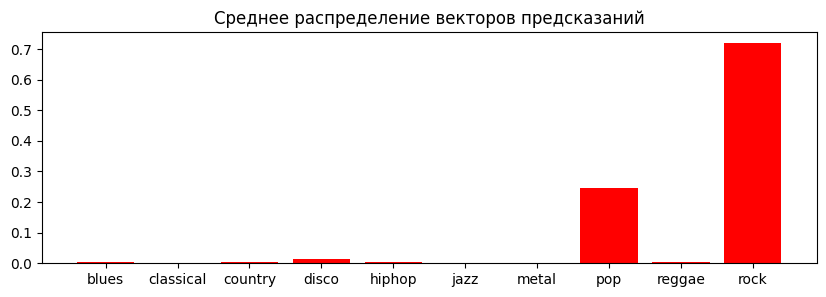

---------------------------------------------------------------
Файл: ./genres/country/country.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


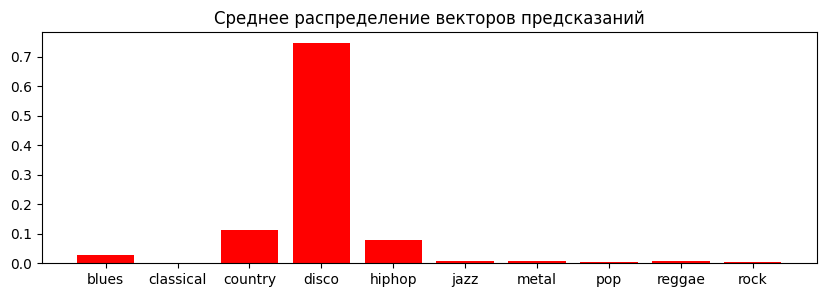

---------------------------------------------------------------
Файл: ./genres/country/country.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


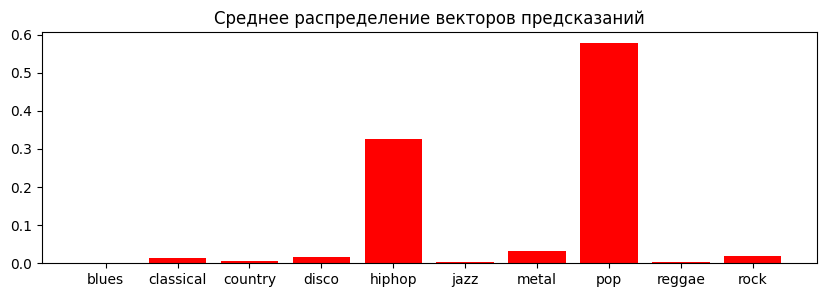

---------------------------------------------------------------
Файл: ./genres/country/country.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


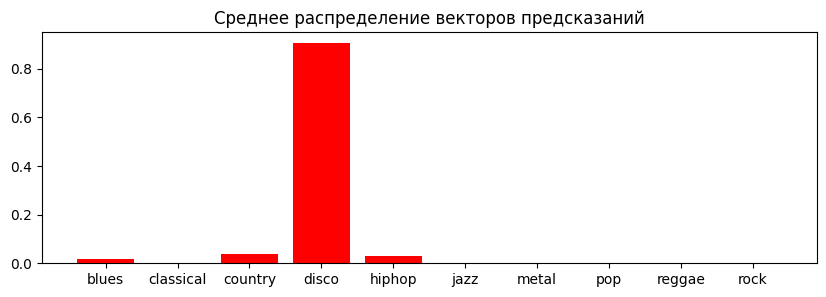

---------------------------------------------------------------
Файл: ./genres/country/country.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


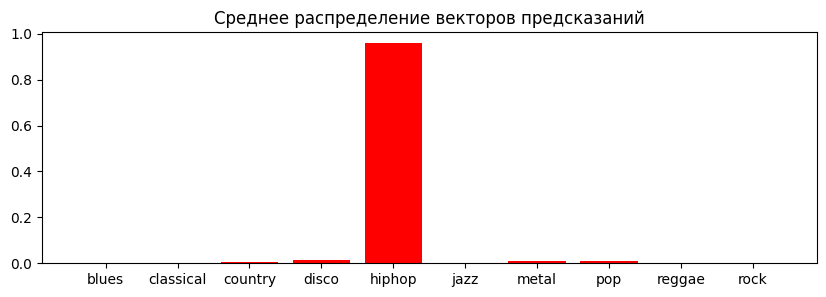

---------------------------------------------------------------
Файл: ./genres/country/country.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


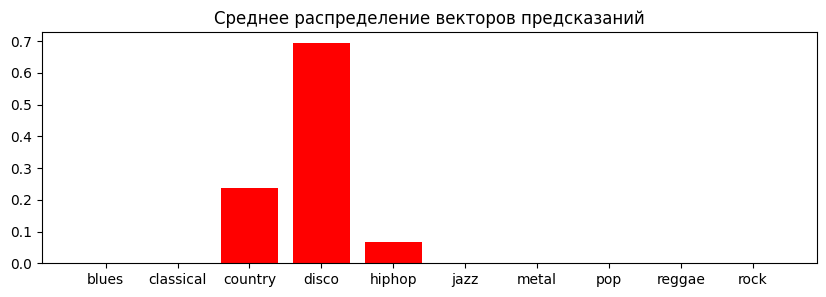

---------------------------------------------------------------
Файл: ./genres/country/country.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


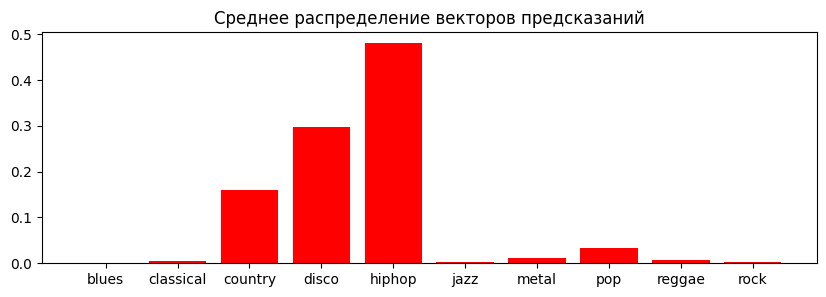

---------------------------------------------------------------
Файл: ./genres/country/country.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


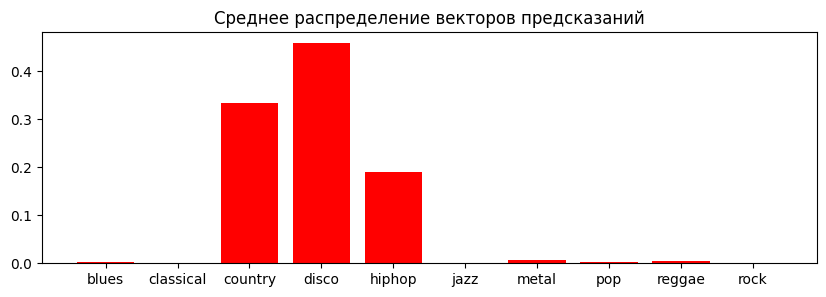

---------------------------------------------------------------
Файл: ./genres/country/country.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


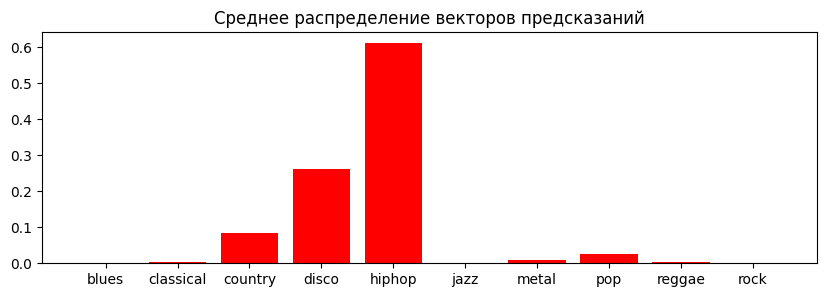

---------------------------------------------------------------
Файл: ./genres/country/country.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


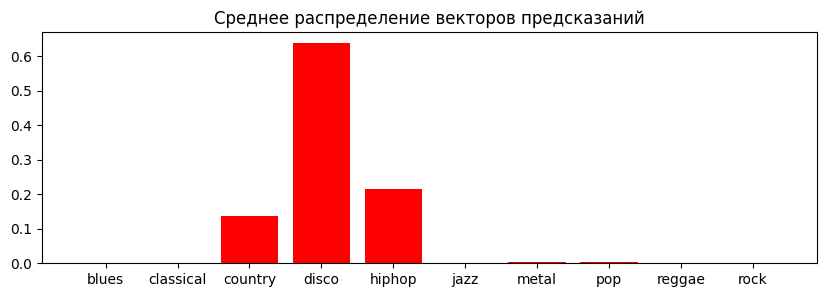

---------------------------------------------------------------
Файл: ./genres/country/country.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


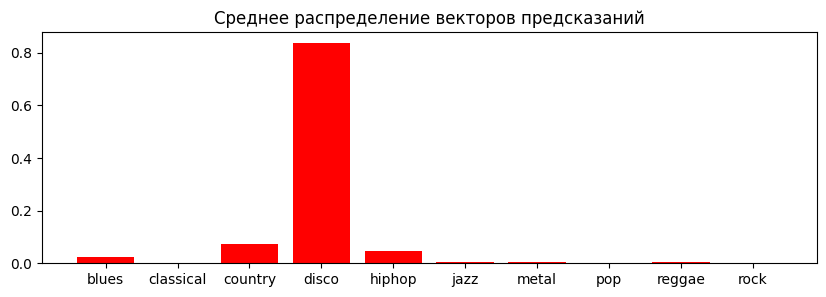

---------------------------------------------------------------
Файл: ./genres/disco/disco.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


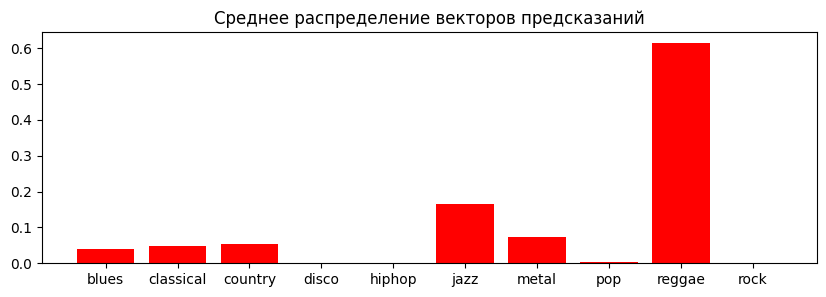

---------------------------------------------------------------
Файл: ./genres/disco/disco.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


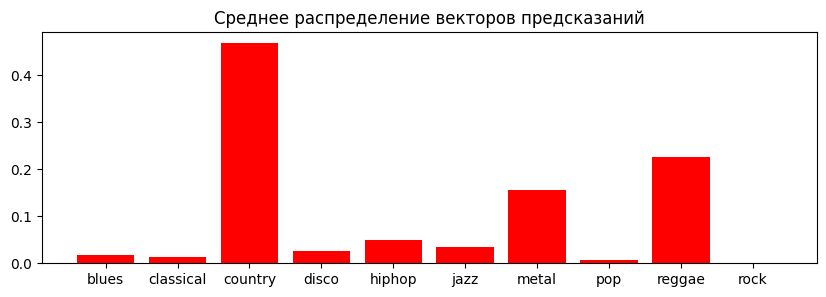

---------------------------------------------------------------
Файл: ./genres/disco/disco.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


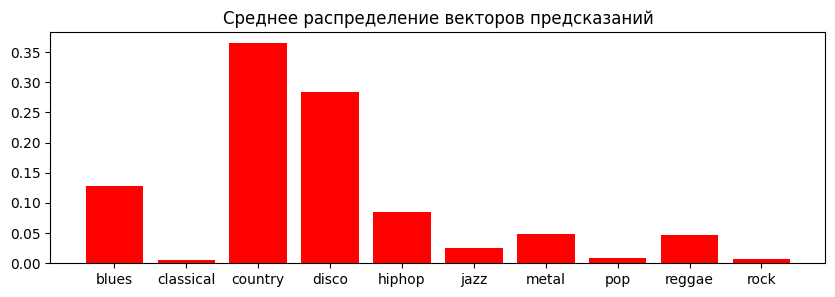

---------------------------------------------------------------
Файл: ./genres/disco/disco.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


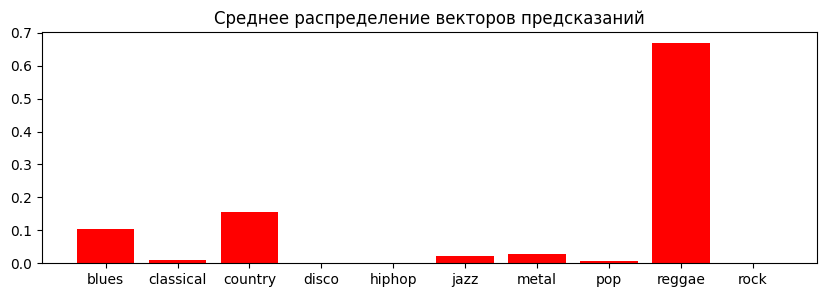

---------------------------------------------------------------
Файл: ./genres/disco/disco.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


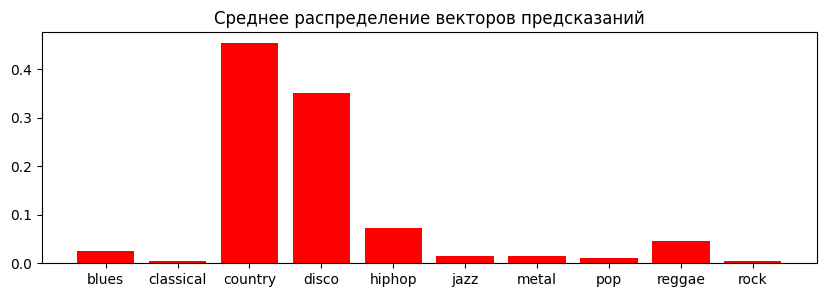

---------------------------------------------------------------
Файл: ./genres/disco/disco.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


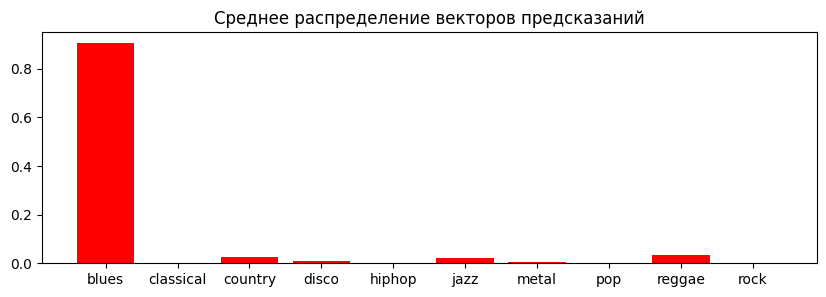

---------------------------------------------------------------
Файл: ./genres/disco/disco.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


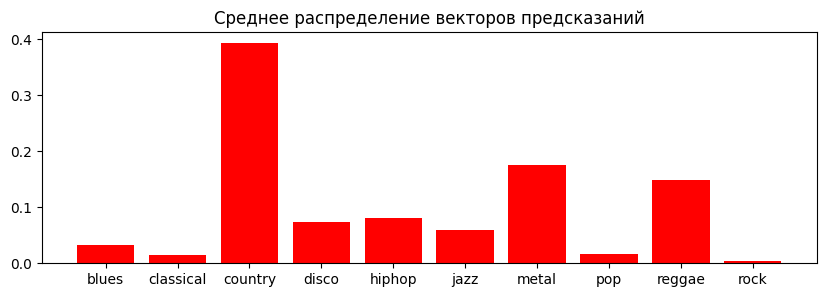

---------------------------------------------------------------
Файл: ./genres/disco/disco.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


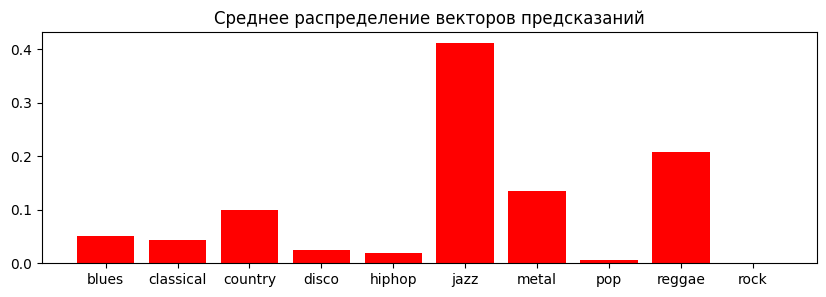

---------------------------------------------------------------
Файл: ./genres/disco/disco.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


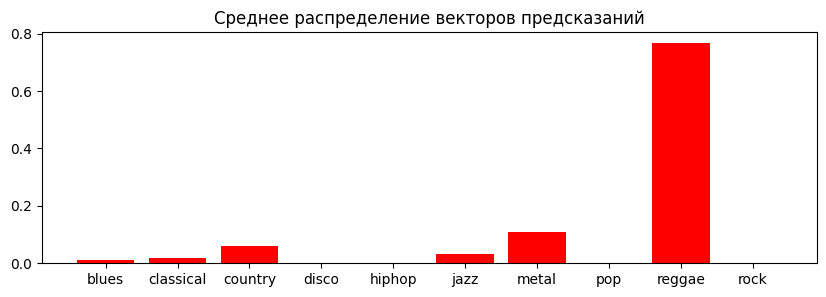

---------------------------------------------------------------
Файл: ./genres/disco/disco.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


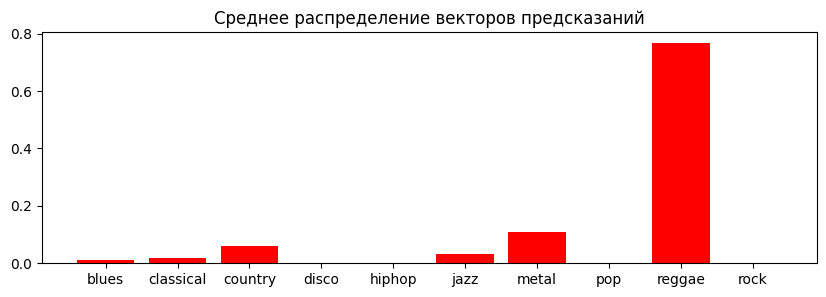

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


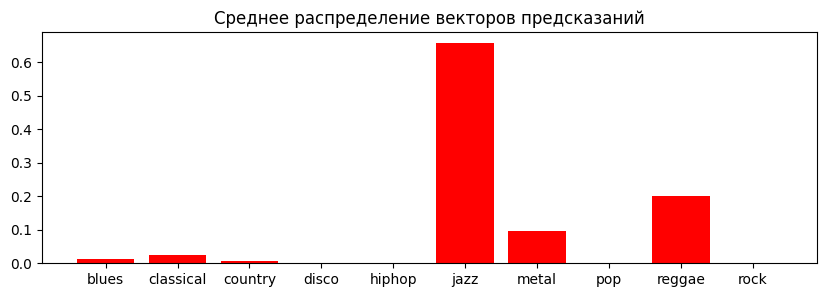

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


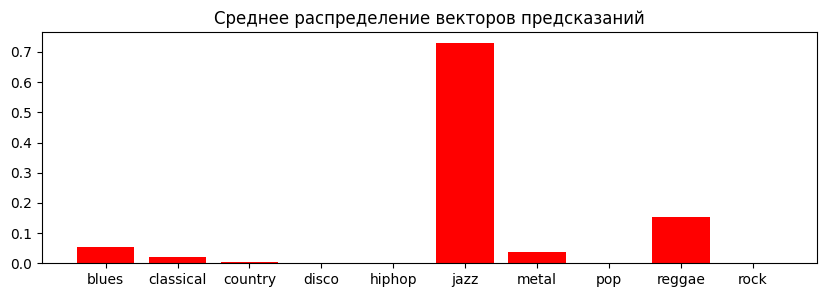

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


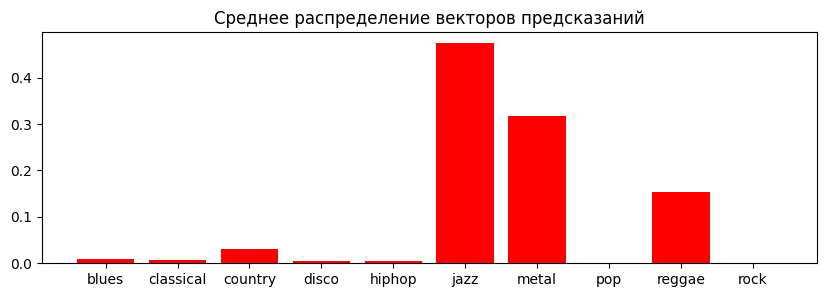

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


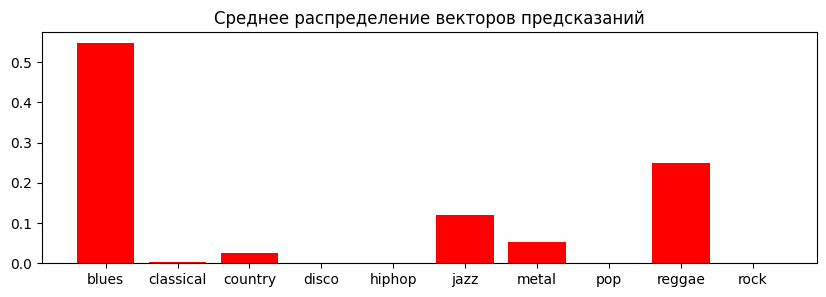

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


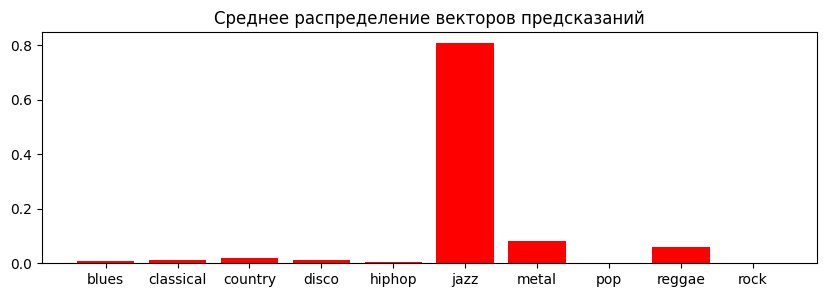

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


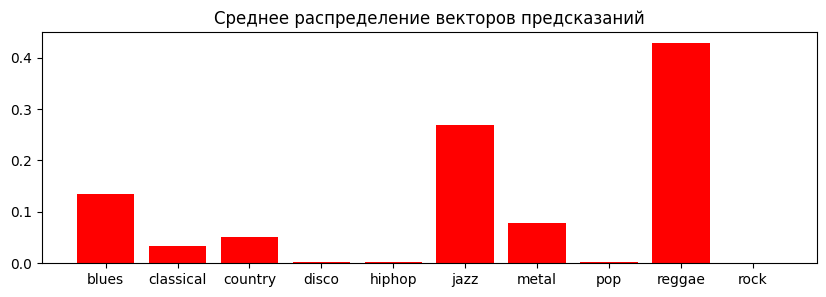

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


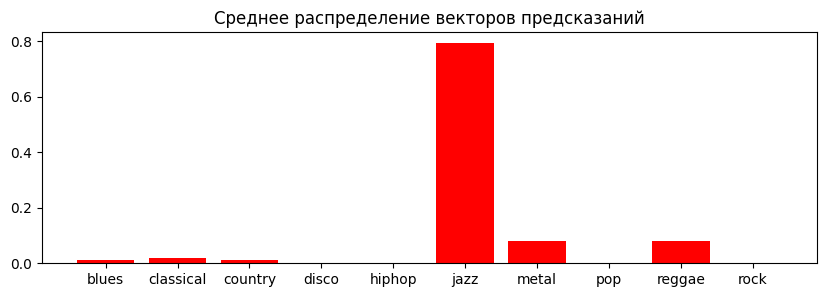

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


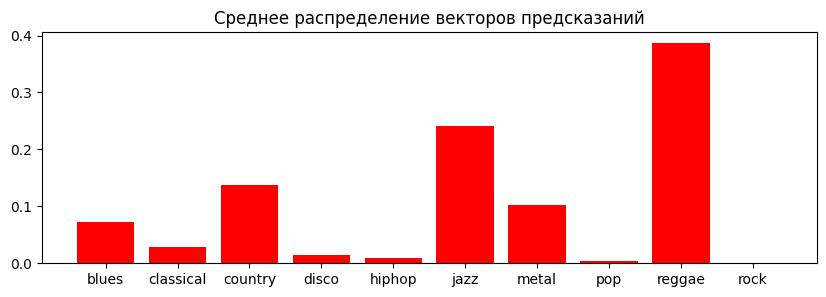

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


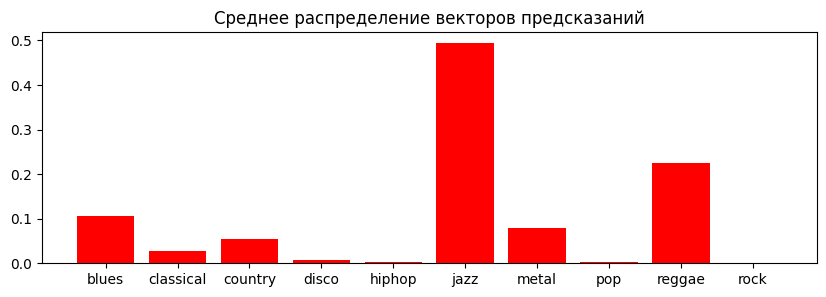

---------------------------------------------------------------
Файл: ./genres/hiphop/hiphop.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


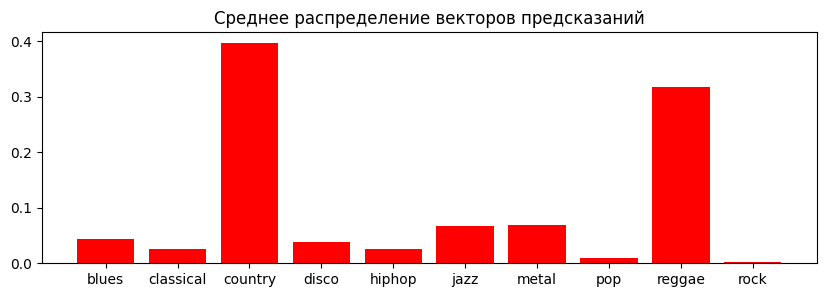

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


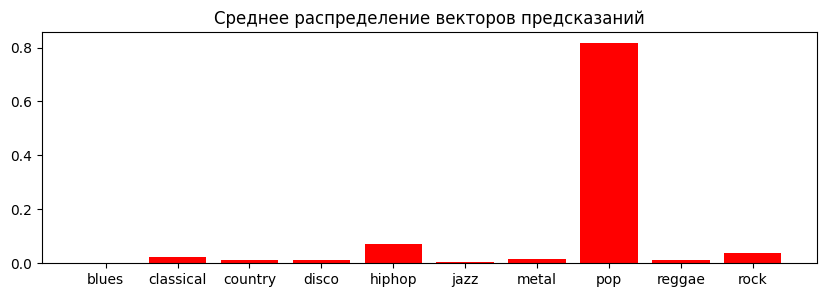

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


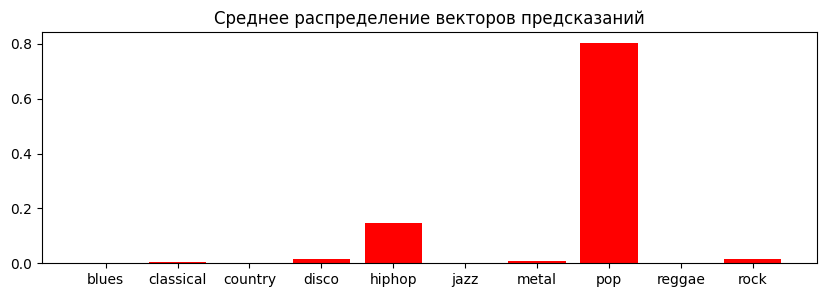

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


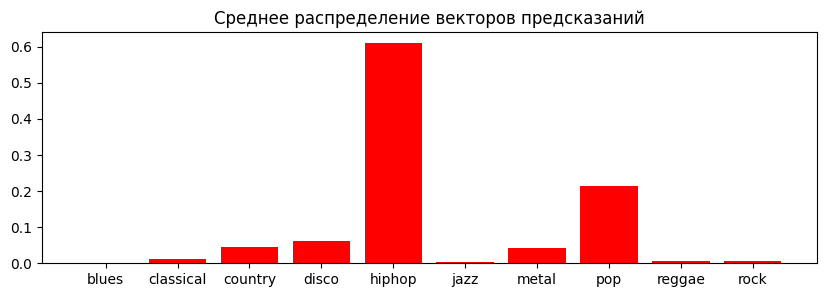

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


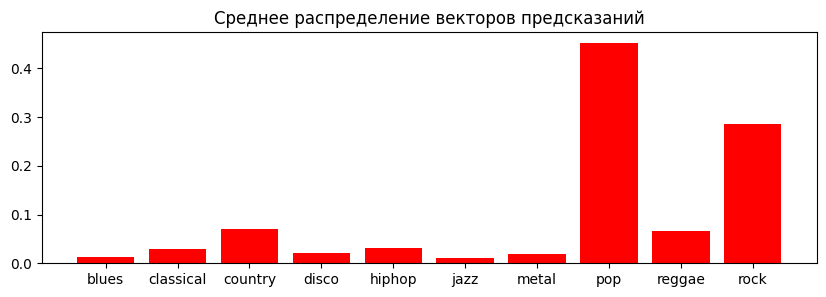

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


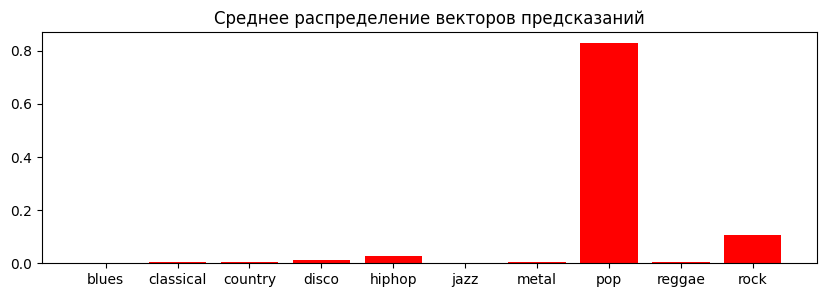

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


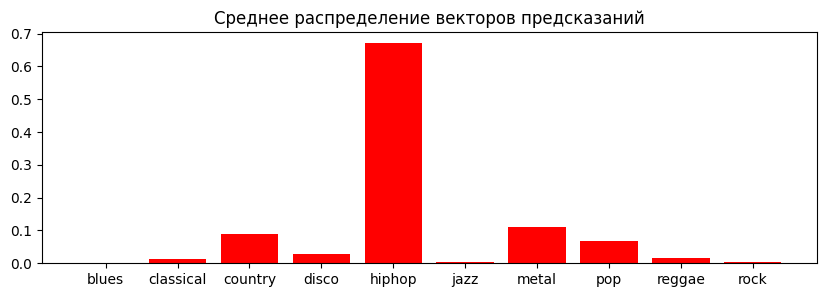

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


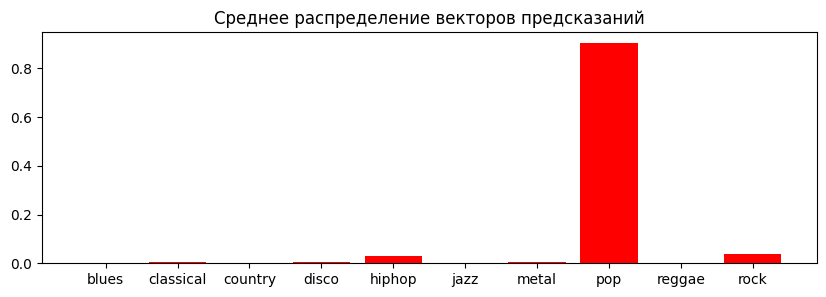

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


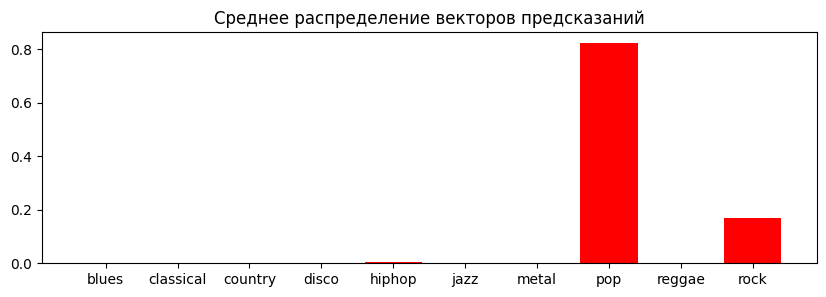

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


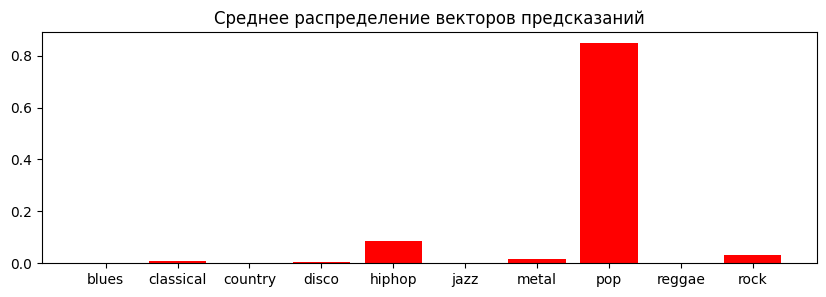

---------------------------------------------------------------
Файл: ./genres/jazz/jazz.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: pop - НЕВЕРНО.


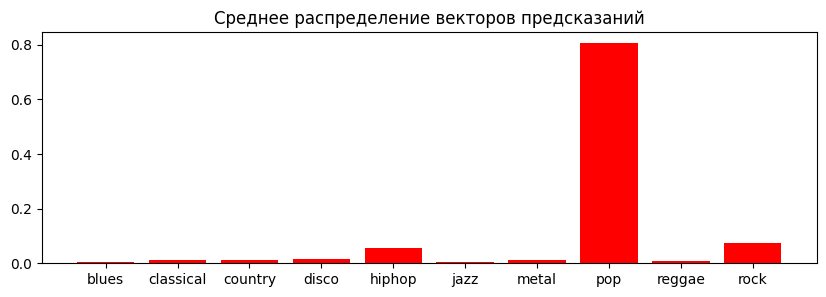

---------------------------------------------------------------
Файл: ./genres/metal/metal.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


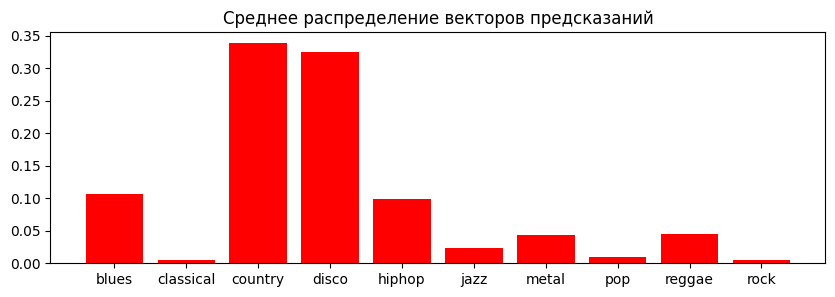

---------------------------------------------------------------
Файл: ./genres/metal/metal.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


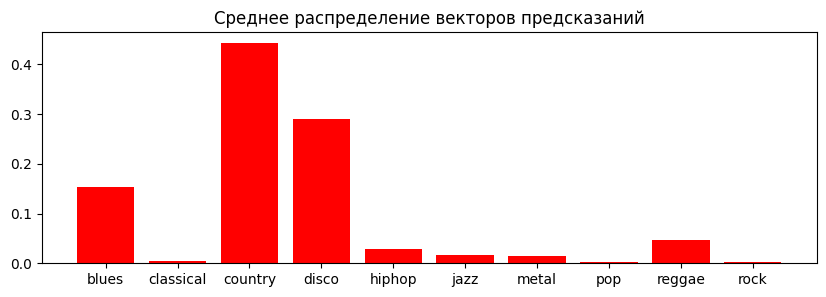

---------------------------------------------------------------
Файл: ./genres/metal/metal.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


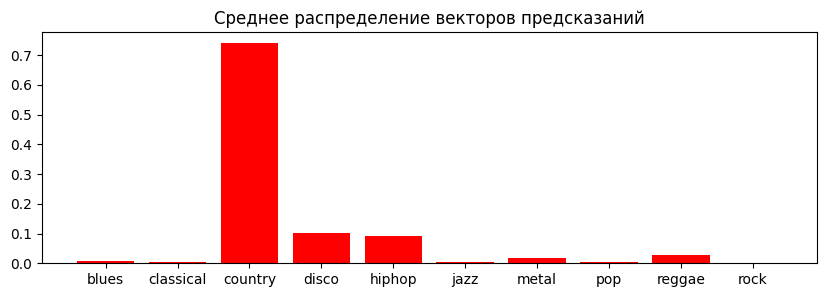

---------------------------------------------------------------
Файл: ./genres/metal/metal.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


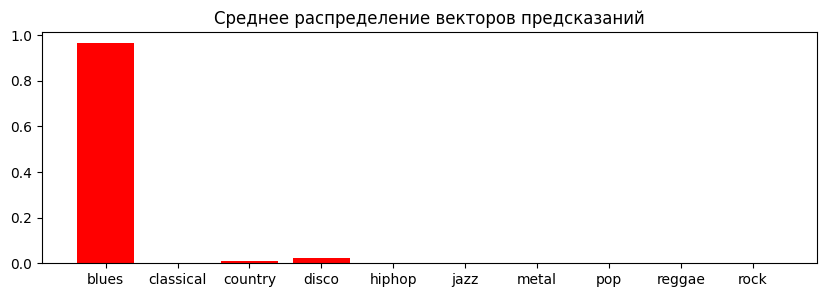

---------------------------------------------------------------
Файл: ./genres/metal/metal.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


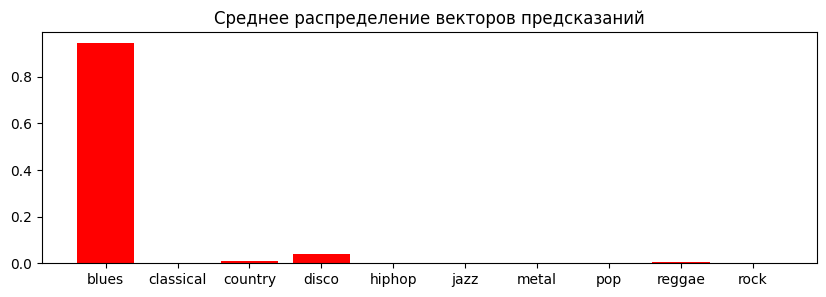

---------------------------------------------------------------
Файл: ./genres/metal/metal.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


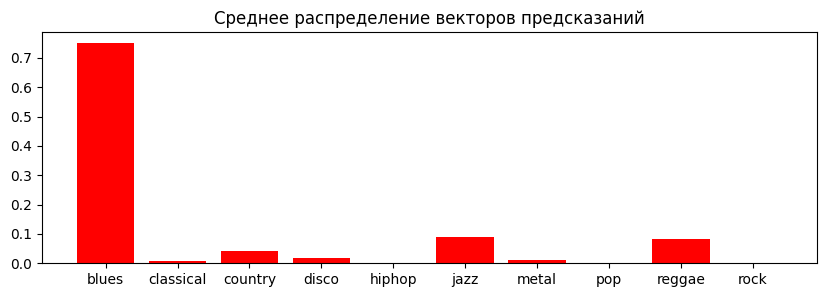

---------------------------------------------------------------
Файл: ./genres/metal/metal.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


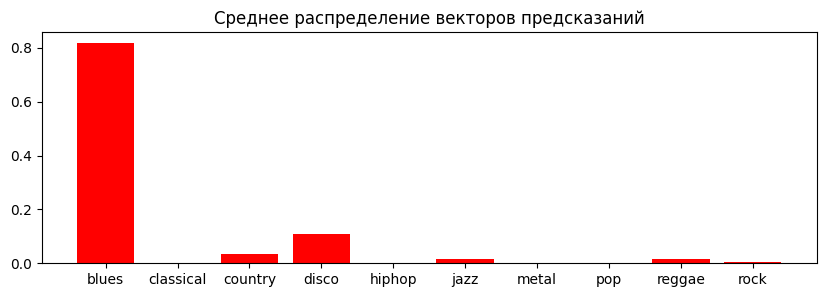

---------------------------------------------------------------
Файл: ./genres/metal/metal.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


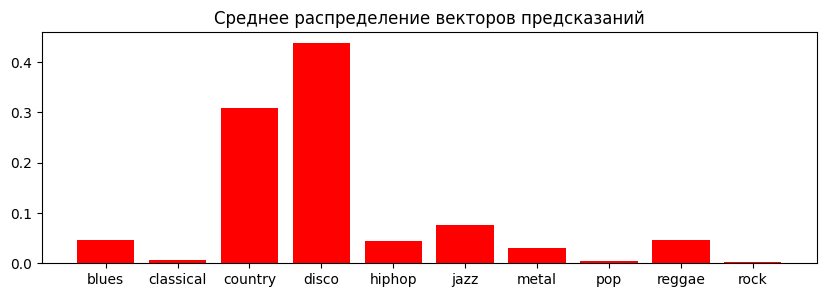

---------------------------------------------------------------
Файл: ./genres/metal/metal.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


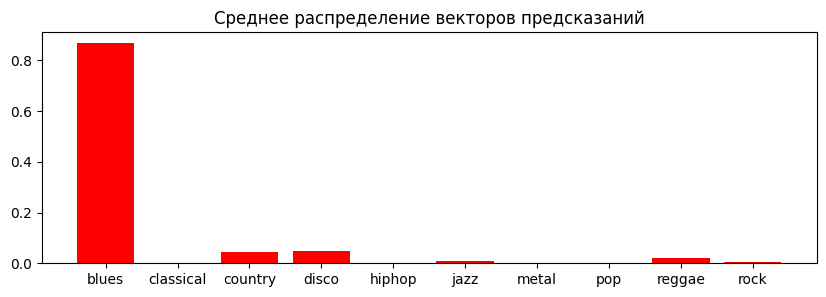

---------------------------------------------------------------
Файл: ./genres/metal/metal.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


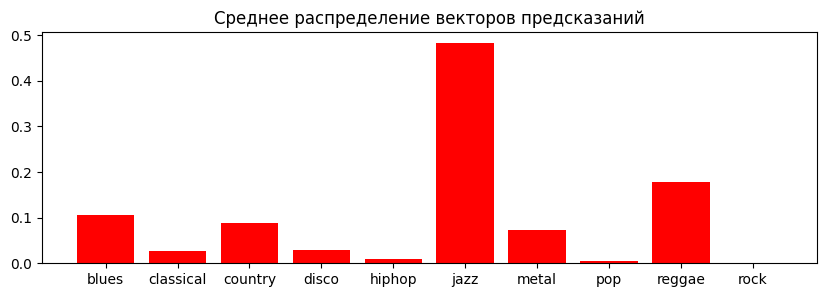

---------------------------------------------------------------
Файл: ./genres/pop/pop.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


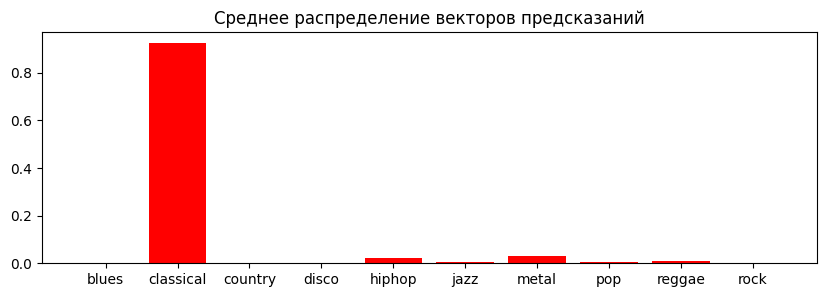

---------------------------------------------------------------
Файл: ./genres/pop/pop.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


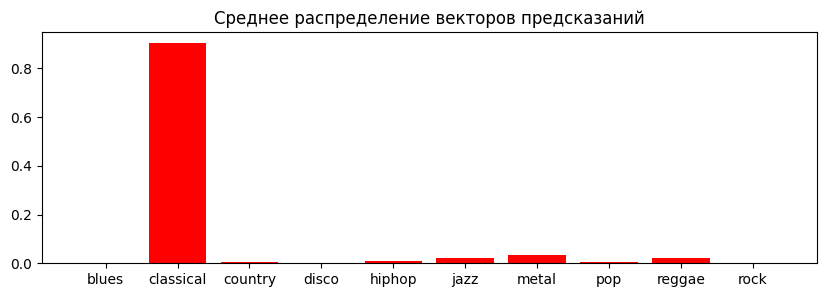

---------------------------------------------------------------
Файл: ./genres/pop/pop.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


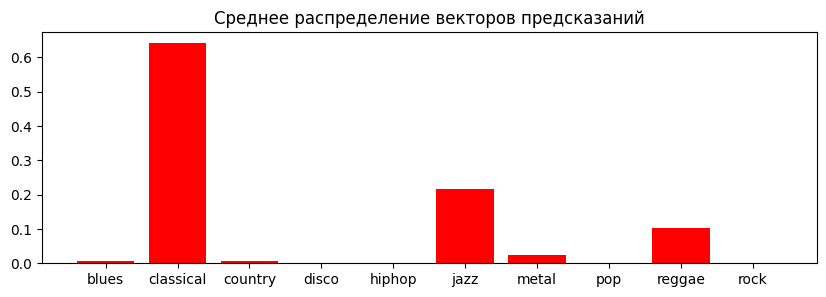

---------------------------------------------------------------
Файл: ./genres/pop/pop.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


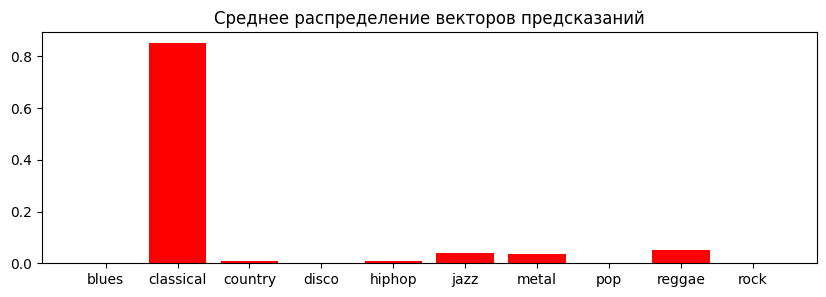

---------------------------------------------------------------
Файл: ./genres/pop/pop.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


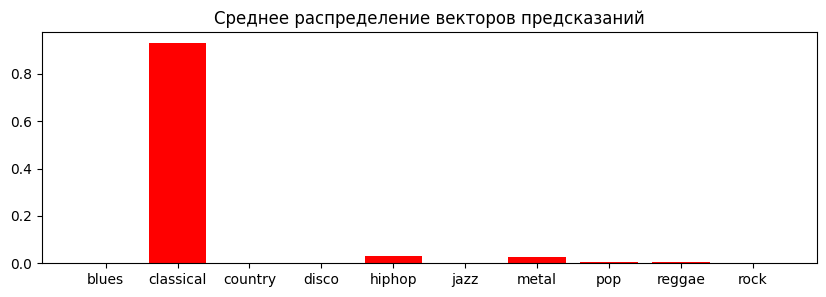

---------------------------------------------------------------
Файл: ./genres/pop/pop.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


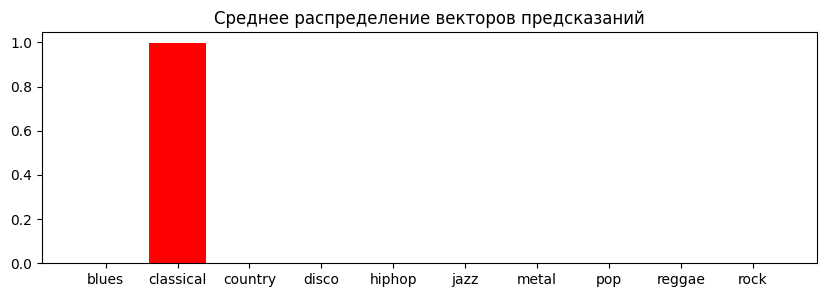

---------------------------------------------------------------
Файл: ./genres/pop/pop.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


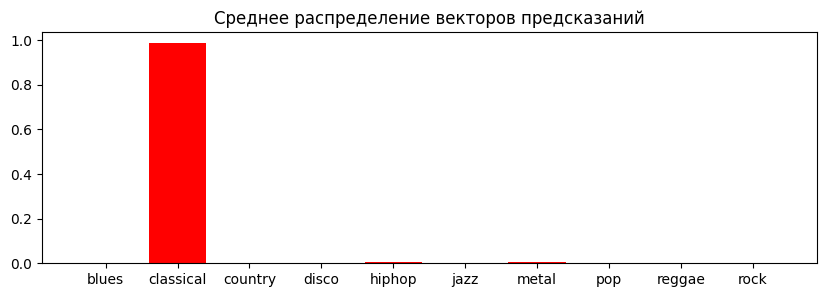

---------------------------------------------------------------
Файл: ./genres/pop/pop.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


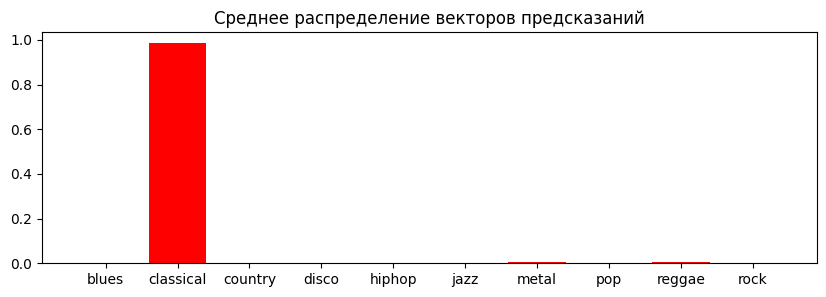

---------------------------------------------------------------
Файл: ./genres/pop/pop.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


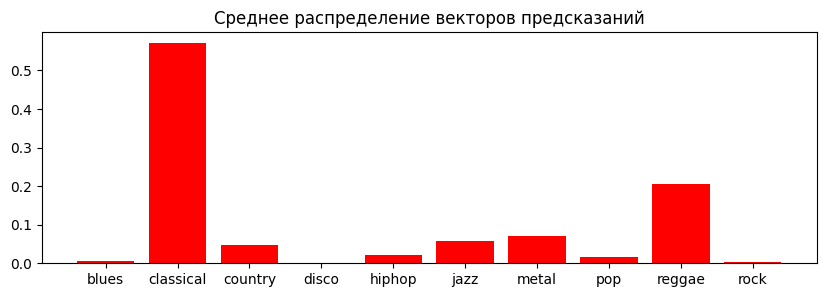

---------------------------------------------------------------
Файл: ./genres/pop/pop.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


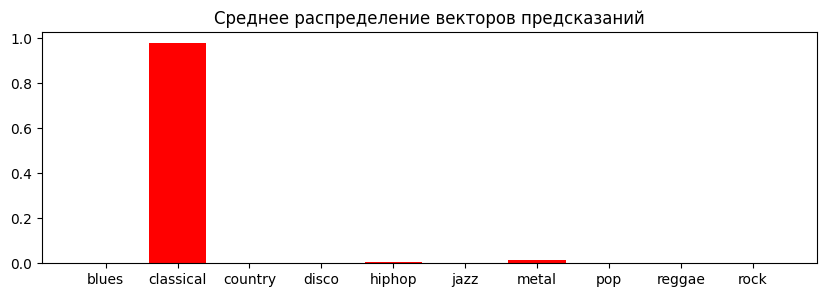

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


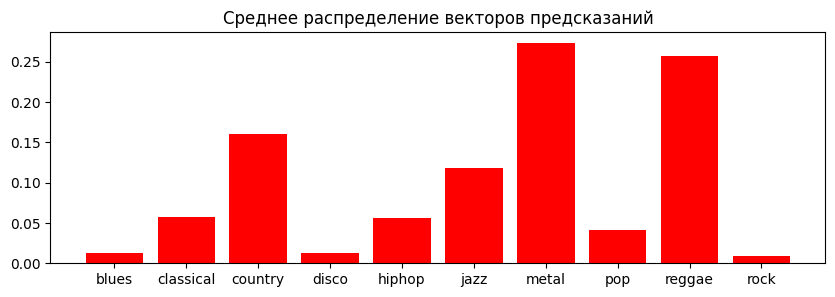

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


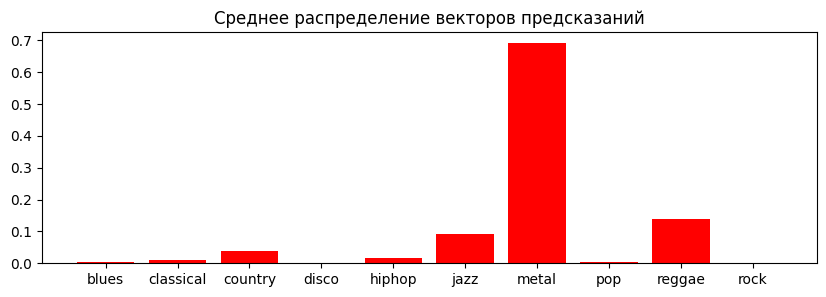

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


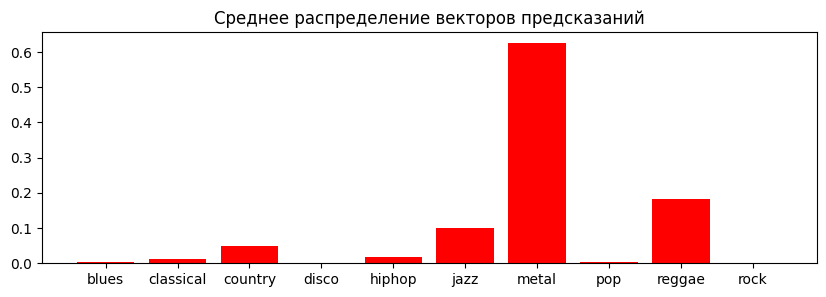

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


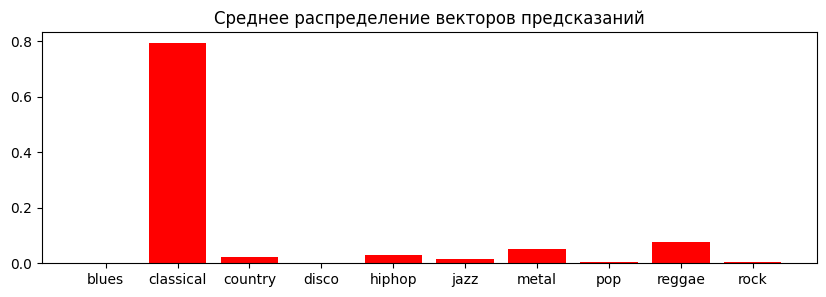

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: classical - НЕВЕРНО.


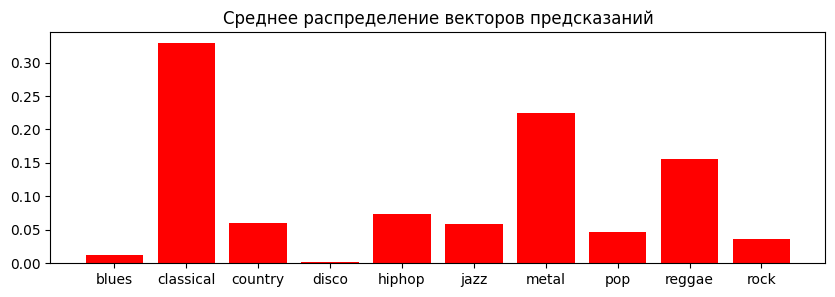

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: jazz - НЕВЕРНО.


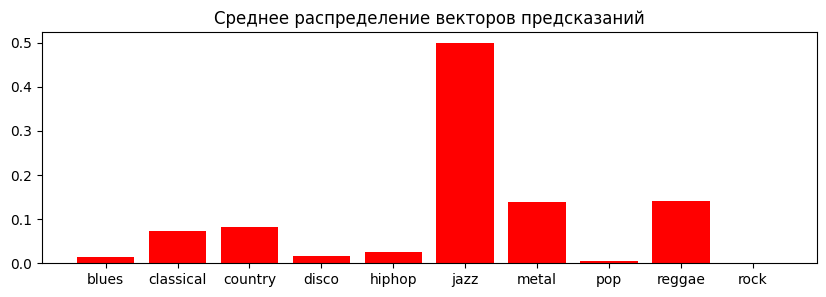

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


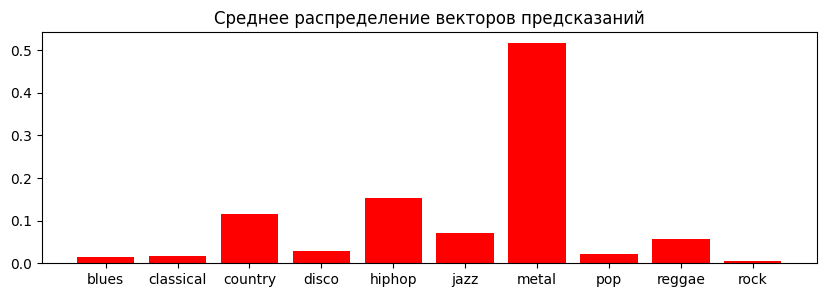

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


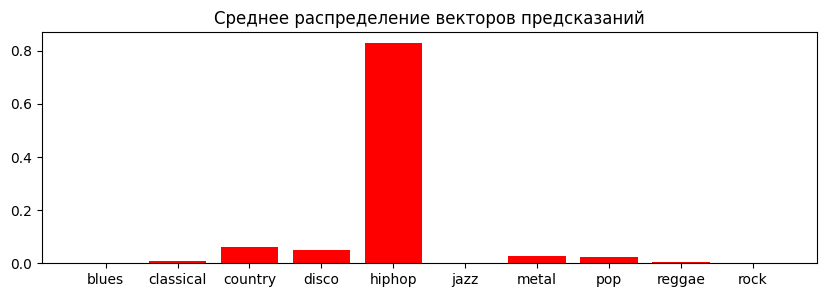

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: metal - НЕВЕРНО.


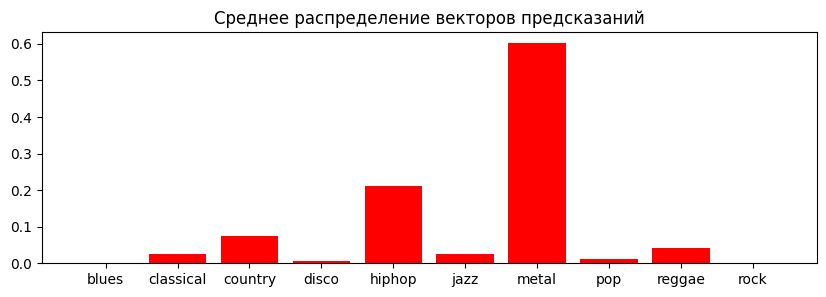

---------------------------------------------------------------
Файл: ./genres/reggae/reggae.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


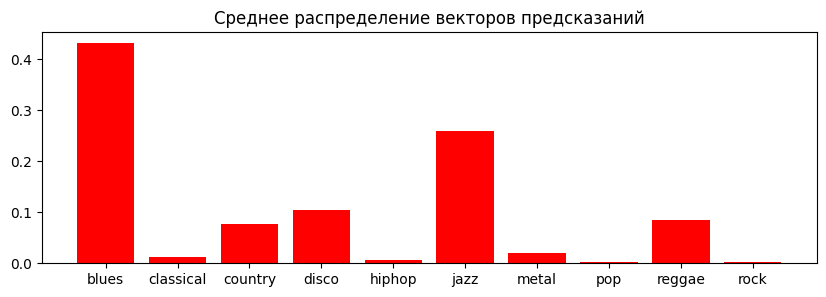

---------------------------------------------------------------
Файл: ./genres/rock/rock.00090.au
Векторы для предсказания: (1, 37)
Классификация сети: disco - НЕВЕРНО.


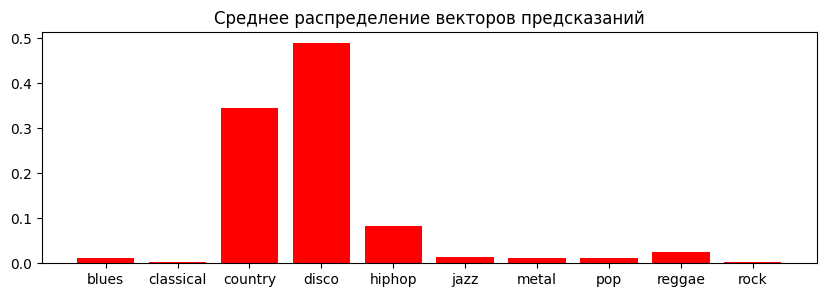

---------------------------------------------------------------
Файл: ./genres/rock/rock.00091.au
Векторы для предсказания: (1, 37)
Классификация сети: reggae - НЕВЕРНО.


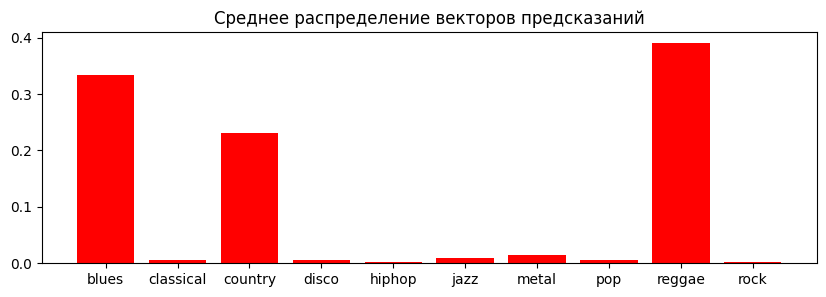

---------------------------------------------------------------
Файл: ./genres/rock/rock.00092.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


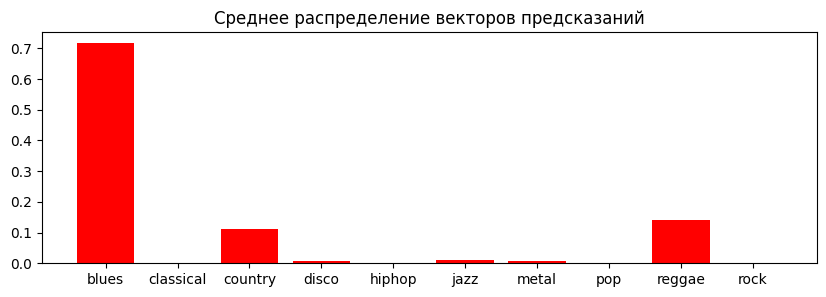

---------------------------------------------------------------
Файл: ./genres/rock/rock.00093.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


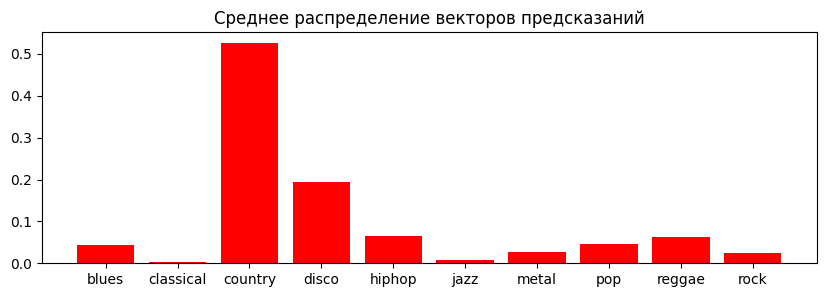

---------------------------------------------------------------
Файл: ./genres/rock/rock.00094.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


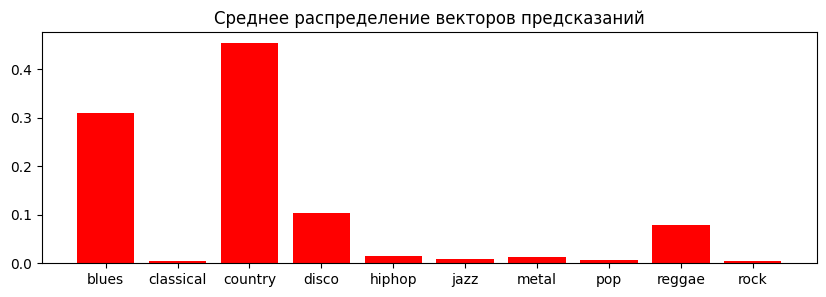

---------------------------------------------------------------
Файл: ./genres/rock/rock.00095.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


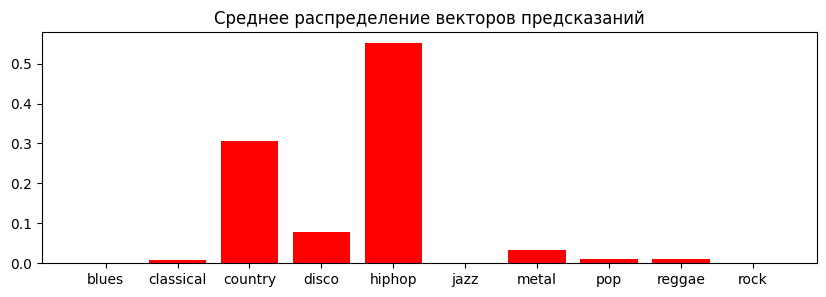

---------------------------------------------------------------
Файл: ./genres/rock/rock.00096.au
Векторы для предсказания: (1, 37)
Классификация сети: country - НЕВЕРНО.


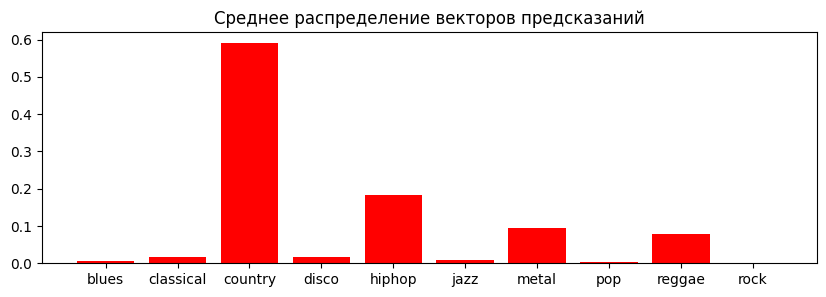

---------------------------------------------------------------
Файл: ./genres/rock/rock.00097.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


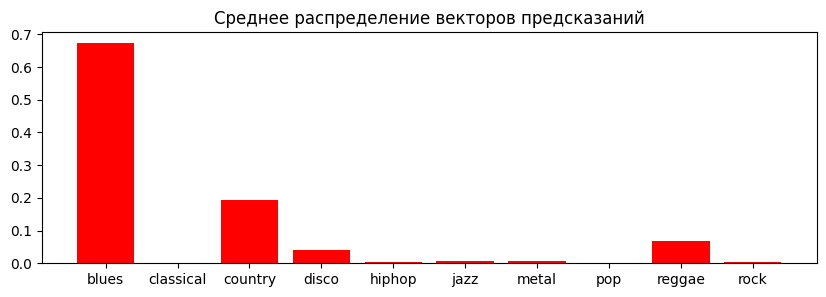

---------------------------------------------------------------
Файл: ./genres/rock/rock.00098.au
Векторы для предсказания: (1, 37)
Классификация сети: hiphop - НЕВЕРНО.


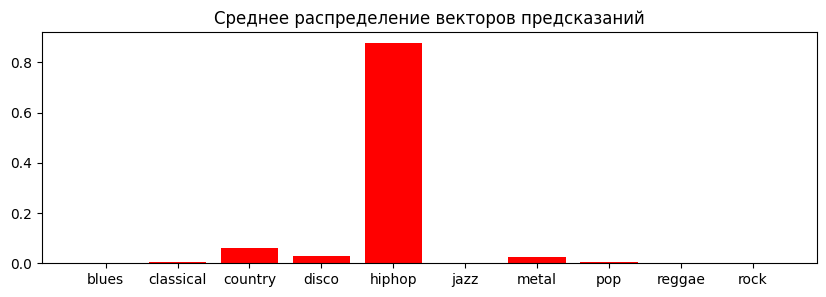

---------------------------------------------------------------
Файл: ./genres/rock/rock.00099.au
Векторы для предсказания: (1, 37)
Классификация сети: blues - НЕВЕРНО.


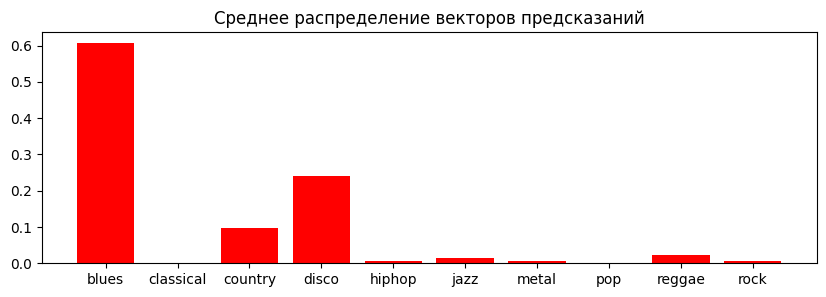

---------------------------------------------------------------
=== Обработано образцов: 100, из них распознано верно: 1, доля верных: 1.0% ===


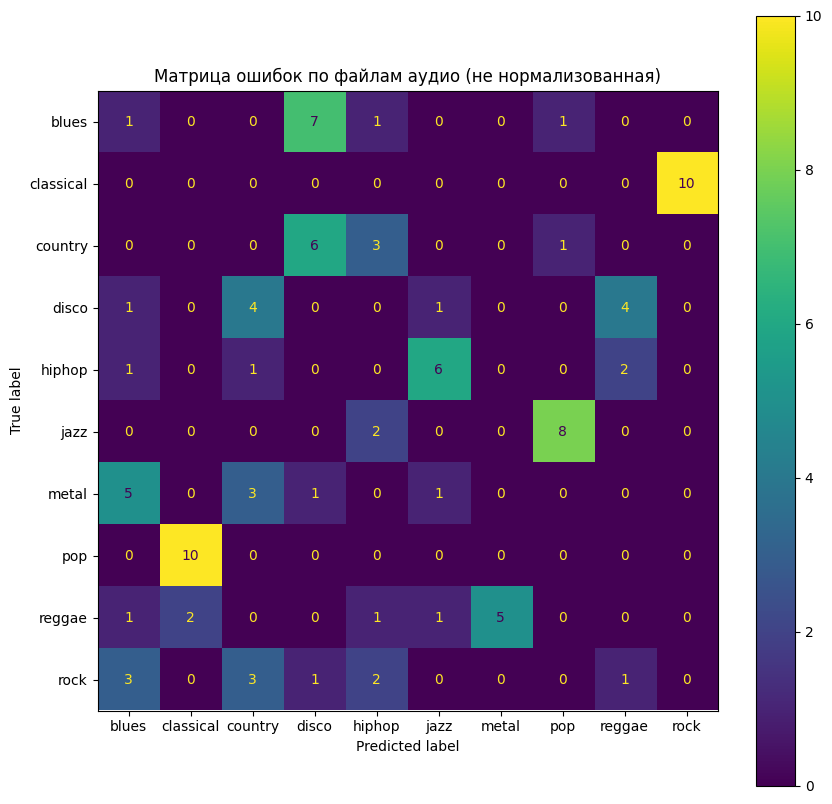

In [ ]:
classify_test_files_torch(
    model=model,
    x_scaler=x_scaler,
    from_index=90,
    n_files=10
)

In [ ]:
model.eval()

with torch.no_grad():
    outputs = model(x_val_t)

    y_pred = torch.argmax(outputs, dim=1).cpu().numpy()
    y_true = y_val_t.cpu().numpy()

# общая точность
correct = np.sum(y_pred == y_true)
total = len(y_true)

print(f'Угадано: {correct} из {total}')
print(f'Точность: {correct / total * 100:.2f}%')

Угадано: 64 из 90
Точность: 71.11%


По результатам проверки модель демонстрирует устойчивое качество классификации на уровне около 71% на валидационной выборке. Это указывает на то, что модель в целом обучилась выделять различия между музыкальными жанрами, однако её обобщающая способность ограничена.

При тестировании на отдельных аудиофайлах точность значительно ниже (около 2%), что связано с особенностями процедуры агрегации предсказаний по временным окнам: модель принимает решение на основе усреднения вероятностей по фрагментам аудиосигнала, что делает итоговый результат чувствительным к шумовым и слабоинформативным участкам записи.